# **Previsão de risco com Machine Learning**

Objetivo: desenvolvimento de modelo preditivo a fim de identificar alunos em risco de defasagem escolar, utilizando dados do PEDE (Pesquisa Extensiva do Desenvolvimento Educacional) de 2022, 2023 e 2024.

O notebook está dividido da seguinte maneira:

1. Tratamento das tabelas PEDE 2022, 2023 e 2024
2. Modelo de Machine Learning
   - Feature Engineering (criação da variável target)
   - Training/testing set (80%/20%)
   - Resultado e avaliação do modelo

* Algoritmo: Random Forest Classifier
* Target: Classificação binária (Sem Risco vs Com Risco de defasagem)
* Saída: Probabilidade de risco de defasagem, posteriormente categorizada em quatro níveis de alerta (Sem Risco, Atenção, Risco Moderado e Risco Alto)
* Validação: Split estratificado 80/20 para treino e teste
* Dataset: Base educacional com 2.467 registros e 11 features

### **1. Tratamento das tabelas PEDE 2022, 2023 e 2024**

**Leitura/tratamento da tabela PEDE 2022**

In [29]:

import pandas as pd
import numpy as np

base_2022 = pd.read_excel(r"C:\Users\user\Desktop\POS-GRADUACAO\DATATHON_FASE5_FIAP_POSTECH\Datathon-Passos-Magicos\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx", sheet_name="PEDE2022")

base_2022.head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [30]:
#Listando colunas

for col in base_2022.columns:
    print(col)

RA
Fase
Turma
Nome
Ano nasc
Idade 22
Gênero
Ano ingresso
Instituição de ensino
Pedra 20
Pedra 21
Pedra 22
INDE 22
Cg
Cf
Ct
Nº Av
Avaliador1
Rec Av1
Avaliador2
Rec Av2
Avaliador3
Rec Av3
Avaliador4
Rec Av4
IAA
IEG
IPS
Rec Psicologia
IDA
Matem
Portug
Inglês
Indicado
Atingiu PV
IPV
IAN
Fase ideal
Defas
Destaque IEG
Destaque IDA
Destaque IPV


In [31]:
# Renomear campos

base_2022 = base_2022.rename(
    columns={
        'RA': 'registro_aluno',
        'Fase': 'fase_aluno',
        'Turma': 'turma',
        'Nome': 'nome',
        'Ano nasc': 'ano_nasc',
        'Idade 22': 'idade',
        'Gênero': 'genero',
        'Ano ingresso': 'ano_inicio_pm',
        'Instituição de ensino': 'instituicao_aluno',
        'Pedra 20': 'classificacao_aluno_2020',
        'Pedra 21': 'classificacao_aluno_2021',
        'Pedra 22': 'classificacao_aluno_2022',
        # 'INDE 22': 'indice_desenvolvimento_educacional',
        'Cg': 'CG', 
        'Cf': 'CF',
        'Ct': 'CT',
        # 'Nº Av': 'numero_avaliador',
        'Avaliador1': 'nome_avaliador1',
        'Rec Av1': 'recomendacao_1',
        'Avaliador2': 'nome_avaliador2',
        'Rec Av2': 'recomendacao_2',
        'Avaliador3': 'nome_avaliador3', 
        'Rec Av3': 'recomendacao_3',
        'Avaliador4': 'nome_avaliador4',
        'Rec Av4': 'recomendacao_4',
        # 'IAA': 'indicador_auto_avaliacao',
        # 'IEG': 'indicador_engajamento',
        # 'IPS': 'indicador_psicossocial', 
        'Rec Psicologia': 'recomendacao_psicologica',
        # 'IDA': 'indicador_aprendizagem',
        'Matem': 'mat',
        'Portug': 'por',
        'Inglês': 'ing',
        'Indicado': 'indicado_por_bolsa',
        # 'Atingiu PV': 'atingiu_ponde_virada',
        # 'IPV': 'indicaor_ponto_virada',
        # 'IAN': 'indicador_adequacao',
        'Fase ideal': 'fase_ideal_aluno',
        'Defas': 'defasagem_aluno',
        'Destaque IEG': 'observacao_engajamento',
        'Destaque IDA': 'observacao_aprendizagem',
        'Destaque IPV': 'observacao_ponto_virada'
    }
)

In [32]:
# Adicionando coluna que identifica o ano a que a tabela se refere

base_2022["ano_base"] = 2022

In [33]:
# resultado das colunas renomeadas

for col in base_2022.columns:
    print(col)

registro_aluno
fase_aluno
turma
nome
ano_nasc
idade
genero
ano_inicio_pm
instituicao_aluno
classificacao_aluno_2020
classificacao_aluno_2021
classificacao_aluno_2022
INDE 22
CG
CF
CT
Nº Av
nome_avaliador1
recomendacao_1
nome_avaliador2
recomendacao_2
nome_avaliador3
recomendacao_3
nome_avaliador4
recomendacao_4
IAA
IEG
IPS
recomendacao_psicologica
IDA
mat
por
ing
indicado_por_bolsa
Atingiu PV
IPV
IAN
fase_ideal_aluno
defasagem_aluno
observacao_engajamento
observacao_aprendizagem
observacao_ponto_virada
ano_base


**Leitura/tratamento da tabela PEDE 2023**

In [34]:

base_2023 = pd.read_excel(r"C:\Users\user\Desktop\POS-GRADUACAO\DATATHON_FASE5_FIAP_POSTECH\Datathon-Passos-Magicos\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx", sheet_name="PEDE2023")

base_2023.head()

,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,...,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,...,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,...,NaN,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,...,NaN,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


In [35]:
#Listando colunas

for col in base_2023.columns:
    print(col)

RA
Fase
INDE 2023
Pedra 2023
Turma
Nome Anonimizado
Data de Nasc
Idade
Gênero
Ano ingresso
Instituição de ensino
Pedra 20
Pedra 21
Pedra 22
Pedra 23
INDE 22
INDE 23
Cg
Cf
Ct
Nº Av
Avaliador1
Rec Av1
Avaliador2
Rec Av2
Avaliador3
Rec Av3
Avaliador4
Rec Av4
IAA
IEG
IPS
IPP
Rec Psicologia
IDA
Mat
Por
Ing
Indicado
Atingiu PV
IPV
IAN
Fase Ideal
Defasagem
Destaque IEG
Destaque IDA
Destaque IPV
Destaque IPV.1


In [36]:
#Remover colunas em branco/duplicadas

base_2023 = base_2023.drop("Pedra 23", axis=1)
base_2023 = base_2023.drop("INDE 23", axis=1)
base_2023 = base_2023.drop("Destaque IPV.1", axis=1)

In [37]:
# Renomear campos

base_2023 = base_2023.rename(
    columns={
        'RA': 'registro_aluno',
        'Fase': 'fase_aluno',
        'Turma': 'turma',
        'Nome Anonimizado': 'nome',
        'Data de Nasc': 'ano_nasc',
        'Idade': 'idade',
        'Gênero': 'genero',
        'Ano ingresso': 'ano_inicio_pm',
        'Instituição de ensino': 'instituicao_aluno',
        'Pedra 20': 'classificacao_aluno_2020',
        'Pedra 21': 'classificacao_aluno_2021',
        'Pedra 22': 'classificacao_aluno_2022',
        'Pedra 2023': 'classificacao_aluno_2023',
        # 'INDE 22': 'indice_desenvolvimento_educacional',
        'INDE 2023': 'INDE 23',
        'Cg': 'CG', 
        'Cf': 'CF',
        'Ct': 'CT',
        # 'Nº Av': 'numero_avaliador',
        'Avaliador1': 'nome_avaliador1',
        'Rec Av1': 'recomendacao_1',
        'Avaliador2': 'nome_avaliador2',
        'Rec Av2': 'recomendacao_2',
        'Avaliador3': 'nome_avaliador3', 
        'Rec Av3': 'recomendacao_3',
        'Avaliador4': 'nome_avaliador4',
        'Rec Av4': 'recomendacao_4',
        # 'IAA': 'indicador_auto_avaliacao',
        # 'IEG': 'indicador_engajamento',
        # 'IPS': 'indicador_psicossocial', 
        'Rec Psicologia': 'recomendacao_psicologica',
        # 'IDA': 'indicador_aprendizagem',
        'Mat': 'mat',
        'Por': 'por',
        'Ing': 'ing',
        'Indicado': 'indicado_por_bolsa',
        # 'Atingiu PV': 'atingiu_ponde_virada',
        # 'IPV': 'indicaor_ponto_virada',
        # 'IAN': 'indicador_adequacao',
        'Fase ideal': 'fase_ideal_aluno',
        'Defasagem': 'defasagem_aluno',
        'Destaque IEG': 'observacao_engajamento',
        'Destaque IDA': 'observacao_aprendizagem',
        'Destaque IPV': 'observacao_ponto_virada'
    }
)

In [38]:
# Adicionando coluna que identifica o ano a que a tabela se refere

base_2023["ano_base"] = 2023

In [39]:
# resultado das colunas renomeadas

for col in base_2023.columns:
    print(col)

registro_aluno
fase_aluno
INDE 23
classificacao_aluno_2023
turma
nome
ano_nasc
idade
genero
ano_inicio_pm
instituicao_aluno
classificacao_aluno_2020
classificacao_aluno_2021
classificacao_aluno_2022
INDE 22
CG
CF
CT
Nº Av
nome_avaliador1
recomendacao_1
nome_avaliador2
recomendacao_2
nome_avaliador3
recomendacao_3
nome_avaliador4
recomendacao_4
IAA
IEG
IPS
IPP
recomendacao_psicologica
IDA
mat
por
ing
indicado_por_bolsa
Atingiu PV
IPV
IAN
Fase Ideal
defasagem_aluno
observacao_engajamento
observacao_aprendizagem
observacao_ponto_virada
ano_base


**Leitura/tratamento da tabela PEDE 2024**

In [40]:

base_2024 = pd.read_excel(r"C:\Users\user\Desktop\POS-GRADUACAO\DATATHON_FASE5_FIAP_POSTECH\Datathon-Passos-Magicos\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx", sheet_name="PEDE2024")

base_2024.head()

,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


In [41]:
#Listando colunas

for col in base_2024.columns:
    print(col)

RA
Fase
INDE 2024
Pedra 2024
Turma
Nome Anonimizado
Data de Nasc
Idade
Gênero
Ano ingresso
Instituição de ensino
Pedra 20
Pedra 21
Pedra 22
Pedra 23
INDE 22
INDE 23
Cg
Cf
Ct
Nº Av
Avaliador1
Rec Av1
Avaliador2
Rec Av2
Avaliador3
Avaliador4
Avaliador5
Avaliador6
IAA
IEG
IPS
IPP
Rec Psicologia
IDA
Mat
Por
Ing
Indicado
Atingiu PV
IPV
IAN
Fase Ideal
Defasagem
Destaque IEG
Destaque IDA
Destaque IPV
Escola
Ativo/ Inativo
Ativo/ Inativo.1


In [42]:
#Remover coluna duplicada

base_2024 = base_2024.drop("Ativo/ Inativo.1", axis=1)

In [43]:
# Renomear campos

base_2024 = base_2024.rename(
    columns={
        'RA': 'registro_aluno',
        'Fase': 'fase_aluno',
        'Turma': 'turma',
        'Nome Anonimizado': 'nome',
        'Data de Nasc': 'ano_nasc',
        'Idade': 'idade',
        'Gênero': 'genero',
        'Ano ingresso': 'ano_inicio_pm',
        'Instituição de ensino': 'instituicao_aluno',
        'Pedra 20': 'classificacao_aluno_2020',
        'Pedra 21': 'classificacao_aluno_2021',
        'Pedra 22': 'classificacao_aluno_2022',
        'Pedra 23': 'classificacao_aluno_2023',
        'Pedra 2024': 'classificacao_aluno_2024',
        # 'INDE 22': 'indice_desenvolvimento_educacional',
        'INDE 2024': 'INDE 24',
        'Cg': 'CG', 
        'Cf': 'CF',
        'Ct': 'CT',
        # 'Nº Av': 'numero_avaliador',
        'Avaliador1': 'nome_avaliador1',
        'Rec Av1': 'recomendacao_1',
        'Avaliador2': 'nome_avaliador2',
        'Rec Av2': 'recomendacao_2',
        'Avaliador3': 'nome_avaliador3', 
        'Avaliador4': 'nome_avaliador4',
        'Avaliador5': 'nome_avaliador5',
        'Avaliador6': 'nome_avaliador6',
        # 'IAA': 'indicador_auto_avaliacao',
        # 'IEG': 'indicador_engajamento',
        # 'IPS': 'indicador_psicossocial', 
        'Rec Psicologia': 'recomendacao_psicologica',
        # 'IDA': 'indicador_aprendizagem',
        'Mat': 'mat',
        'Por': 'por',
        'Ing': 'ing',
        'Indicado': 'indicado_por_bolsa',
        # 'Atingiu PV': 'atingiu_ponde_virada',
        # 'IPV': 'indicaor_ponto_virada',
        # 'IAN': 'indicador_adequacao',
        'Fase ideal': 'fase_ideal_aluno',
        'Defasagem': 'defasagem_aluno',
        'Destaque IEG': 'observacao_engajamento',
        'Destaque IDA': 'observacao_aprendizagem',
        'Destaque IPV': 'observacao_ponto_virada'
    }
)

In [44]:
# Adicionando coluna que identifica o ano a que a tabela se refere

base_2024["ano_base"] = 2024

In [45]:
# resultado das colunas renomeadas

for col in base_2024.columns:
    print(col)

registro_aluno
fase_aluno
INDE 24
classificacao_aluno_2024
turma
nome
ano_nasc
idade
genero
ano_inicio_pm
instituicao_aluno
classificacao_aluno_2020
classificacao_aluno_2021
classificacao_aluno_2022
classificacao_aluno_2023
INDE 22
INDE 23
CG
CF
CT
Nº Av
nome_avaliador1
recomendacao_1
nome_avaliador2
recomendacao_2
nome_avaliador3
nome_avaliador4
nome_avaliador5
nome_avaliador6
IAA
IEG
IPS
IPP
recomendacao_psicologica
IDA
mat
por
ing
indicado_por_bolsa
Atingiu PV
IPV
IAN
Fase Ideal
defasagem_aluno
observacao_engajamento
observacao_aprendizagem
observacao_ponto_virada
Escola
Ativo/ Inativo
ano_base


**Após padronizar o nome das colunas, irá concatenar os dados dos três anos (2022,2023 e 2024)**

In [46]:
#Concatenando as tabelas

base_final = pd.concat([base_2022, base_2023, base_2024], ignore_index=True)

In [47]:

base_final.head()

,registro_aluno,fase_aluno,turma,nome,ano_nasc,idade,genero,ano_inicio_pm,instituicao_aluno,classificacao_aluno_2020,...,INDE 23,classificacao_aluno_2023,IPP,Fase Ideal,INDE 24,classificacao_aluno_2024,nome_avaliador5,nome_avaliador6,Escola,Ativo/ Inativo
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# Dimensões da base

base_final.shape

(3030, 53)

In [49]:
# Valores nulos

base_final.isnull().sum()

registro_aluno                 0
fase_aluno                     0
turma                          0
nome                           0
ano_nasc                       0
idade                          0
genero                         0
ano_inicio_pm                  0
instituicao_aluno              1
classificacao_aluno_2020    2276
classificacao_aluno_2021    1969
classificacao_aluno_2022    1098
INDE 22                     1098
CG                          2170
CF                          2170
CT                          2170
Nº Av                         76
nome_avaliador1              203
recomendacao_1              2170
nome_avaliador2              203
recomendacao_2              2170
nome_avaliador3              996
recomendacao_3              2170
nome_avaliador4             1979
recomendacao_4              2734
IAA                          165
IEG                           76
IPS                          171
recomendacao_psicologica    2170
IDA                          178
mat       

**Transformando colunas numéricas**

In [50]:

base_final['IAA']=base_final['IAA'].astype(float)
base_final['IEG']=base_final['IEG'].astype(float)
base_final['IPS']=base_final['IPS'].astype(float)
base_final['IDA']=base_final['IDA'].astype(float)
base_final['IPV']=base_final['IPV'].astype(float)
base_final['IPP']=base_final['IPP'].astype(float)
base_final['mat']=base_final['mat'].astype(float)
base_final['por']=base_final['por'].astype(float)
base_final['ing']=base_final['ing'].astype(float)
base_final['IPV']=base_final['IPV'].astype(float)
base_final['IAN']=base_final['IAN'].astype(float)
base_final['INDE 22']=base_final['INDE 22'].astype(float)
base_final['INDE 23']=base_final['INDE 23'].astype(float)
base_final["INDE 24"] = pd.to_numeric(base_final["INDE 24"], errors="coerce")
base_final['CG']=base_final['CG'].astype(float)
base_final['CF']=base_final['CF'].astype(float)
base_final['CT']=base_final['CT'].astype(float)


 **Criando coluna "INDE" para agregar os três anos (INDE 22,23 e 24) em uma única coluna**

In [51]:


base_final["INDE"] = np.where(
    base_final["ano_base"] == 2022, base_final["INDE 22"],
    np.where(
        base_final["ano_base"] == 2023, base_final["INDE 23"],
        base_final["INDE 24"]
    )
)

In [52]:
base_final.isna().sum()

registro_aluno                 0
fase_aluno                     0
turma                          0
nome                           0
ano_nasc                       0
idade                          0
genero                         0
ano_inicio_pm                  0
instituicao_aluno              1
classificacao_aluno_2020    2276
classificacao_aluno_2021    1969
classificacao_aluno_2022    1098
INDE 22                     1098
CG                          2170
CF                          2170
CT                          2170
Nº Av                         76
nome_avaliador1              203
recomendacao_1              2170
nome_avaliador2              203
recomendacao_2              2170
nome_avaliador3              996
recomendacao_3              2170
nome_avaliador4             1979
recomendacao_4              2734
IAA                          165
IEG                           76
IPS                          171
recomendacao_psicologica    2170
IDA                          178
mat       

## **2. Modelo de Machine Learning**

* Algoritmo: Random Forest Classifier. O algoritmo Random Forest Classifier foi escolhido por sua capacidade de lidar bem com múltiplas variáveis e capturar relações não lineares entre os dados. Além disso, é um modelo robusto, menos sensível a overfitting e apresenta bom desempenho em problemas de classificação, como a previsão do risco de defasagem escolar.
* Variável target: "defasagem_aluno". Esta veriável foi escolhida pois representa diretamente a condição de atraso educacional do estudante em relação à fase de ensino ideal para sua idade, além de demonstrar boa completude de dados (N/A=0), e ser possível utilizá-la como classificação binária.

In [53]:
# Mantendo somente colunas necessárias (tirando as que possuem maior quantidade de nulos/causam ruído/causam Data Leakage)

colunas_remover = [
"IPP",
"INDE",    
"INDE 22",
"INDE 23",
"INDE 24",
"classificacao_aluno_2024",
"classificacao_aluno_2023",
"classificacao_aluno_2022",
"classificacao_aluno_2021",
"classificacao_aluno_2020",
"nome_avaliador1",
"nome_avaliador2",
"nome_avaliador3",
"nome_avaliador4",
"nome_avaliador5",
"nome_avaliador6",
"observacao_engajamento",
"observacao_aprendizagem",
"observacao_ponto_virada",
"recomendacao_1",
"recomendacao_2",
"recomendacao_3",
"recomendacao_4",
"recomendacao_psicologica",
"registro_aluno",
"nome",
"Fase Ideal",
"fase_ideal_aluno",
"Atingiu PV",
"IAN",
"IPV"
]

base_modelo = base_final.drop(columns=colunas_remover, errors="ignore")

In [54]:
base_modelo.isna().sum()

fase_aluno               0
turma                    0
ano_nasc                 0
idade                    0
genero                   0
ano_inicio_pm            0
instituicao_aluno        1
CG                    2170
CF                    2170
CT                    2170
Nº Av                   76
IAA                    165
IEG                     76
IPS                    171
IDA                    178
mat                    184
por                    185
ing                   1939
indicado_por_bolsa    2170
defasagem_aluno          0
ano_base                 0
Escola                1875
Ativo/ Inativo        1874
dtype: int64

### **• Feature Engineering**

In [55]:
# Definindo a variável Target (defasagem_aluno) e transformando em classificação binária

base_modelo["risco_defasagem"] = (base_modelo["defasagem_aluno"] < 0).astype(int)

In [56]:
# Removendo "defasagem_aluno" para evitar vazamento

colunas_remover = [
"defasagem_aluno",

]

base_modelo = base_modelo.drop(columns=colunas_remover)

In [57]:
# Verificando resultado

base_modelo.isna().sum()

fase_aluno               0
turma                    0
ano_nasc                 0
idade                    0
genero                   0
ano_inicio_pm            0
instituicao_aluno        1
CG                    2170
CF                    2170
CT                    2170
Nº Av                   76
IAA                    165
IEG                     76
IPS                    171
IDA                    178
mat                    184
por                    185
ing                   1939
indicado_por_bolsa    2170
ano_base                 0
Escola                1875
Ativo/ Inativo        1874
risco_defasagem          0
dtype: int64

In [58]:
# Selecionar variáveis preditoras

X = base_modelo.drop(columns=["risco_defasagem"])
y = base_modelo["risco_defasagem"]

In [59]:
# Transformar variáveis categóricas

X = pd.get_dummies(X, drop_first=True)

### **• Training/testing set (80%/20%)**

In [60]:
# Separando treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [61]:
# Treinar o modelo

from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

modelo.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### **• Resultado e avaliação do modelo**


=== Avaliação do Modelo ===
Acurácia: 0.873

Relatório de Classificação:
              precision  recall  f1-score  support
0                 0.902   0.797     0.846  266.000
1                 0.854   0.932     0.892  340.000
accuracy          0.873   0.873     0.873    0.873
macro avg         0.878   0.865     0.869  606.000
weighted avg      0.875   0.873     0.872  606.000


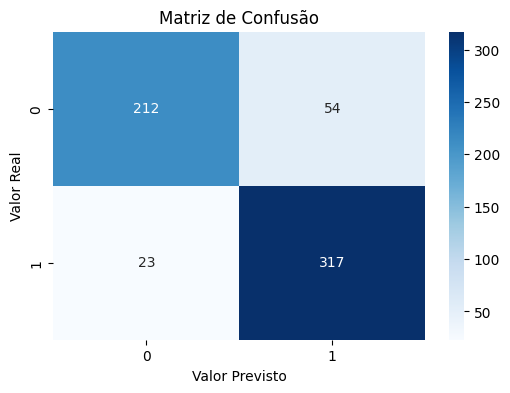

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Previsões
pred = modelo.predict(X_test)

# Acurácia
accuracy = accuracy_score(y_test, pred)

print("\n=== Avaliação do Modelo ===")
print(f"Acurácia: {accuracy:.3f}\n")

# Relatório de classificação
report = classification_report(y_test, pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("Relatório de Classificação:")
print(df_report.round(3))

# Matriz de confusão
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão")
plt.ylabel("Valor Real")
plt.xlabel("Valor Previsto")

plt.show()

In [63]:
# Gerar probabilidade de risco de defasagem

prob = modelo.predict_proba(X_test)[:,1]

In [64]:
# Variáveis importantes do modelo (quais variáveis mais influenciam no risco de defasagem)

import pandas as pd

importancia = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancia.head(10))

IEG      0.046190
IDA      0.045332
por      0.043370
mat      0.038966
IAA      0.035865
IPS      0.035484
Nº Av    0.027990
ing      0.026720
CF       0.026070
CG       0.024670
dtype: float64


In [65]:
base_modelo.to_csv(r"C:\Users\user\Desktop\POS-GRADUACAO\DATATHON_FASE5_FIAP_POSTECH\Datathon-Passos-Magicos\data\base_processada.csv", index=False)